In [244]:
import gymnasium as gym
import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt
import torch 

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

In [245]:
device

device(type='mps')

## Get to know torch

In [246]:
torch.tensor([[1, 2], [1, 2]])

tensor([[1, 2],
        [1, 2]])

In [247]:
# Many functions are similar to numpy
x = torch.ones(2, 3)  # 2 times 3 matrix of ones

y = torch.zeros(2, 3)  # 2 times 3 matrix of zeros

z = torch.cat((x, y), dim=1)  # concatenate two tensors along specified dimension

print(z)
print(z.shape)

tensor([[1., 1., 1., 0., 0., 0.],
        [1., 1., 1., 0., 0., 0.]])
torch.Size([2, 6])


In [248]:
values = torch.tensor([[2, 1.5], [0.5, 1]], dtype=float)

print(values)

print("Column-wise argmax:", torch.argmax(values, dim=0))  # index of max value for each column

print("Row-wise argmax:", torch.argmax(values, dim=1))  # index of max value for each row

tensor([[2.0000, 1.5000],
        [0.5000, 1.0000]], dtype=torch.float64)
Column-wise argmax: tensor([0, 0])
Row-wise argmax: tensor([0, 1])


In [249]:
scalar = torch.tensor(1)
print(scalar)
print(scalar.shape)
print(scalar.item())  # extract torche scalar value from a tensor of size 0 or 1

tensor(1)
torch.Size([])
1


In [250]:
array = np.ones(3)
tensor = torch.as_tensor(array)  # convert numpy array into pytorch tensor
new_array = tensor.detach().cpu().numpy()  # convert pytorch tensor into numpy array
print(new_array)
print(tensor)

[1. 1. 1.]
tensor([1., 1., 1.], dtype=torch.float64)


In [251]:
import torch.nn as nn  # pytorch library for neural networks https://docs.pytorch.org/tutorials/beginner/pytorch_witorch_examples.html#pytorch-nn

input = torch.zeros(3)

# A tiny neural network (one hidden layer)
model = nn.Sequential(
    nn.Linear(3, 2),  # a fully connexted layer, maps 3-dimensional data to 2-dimensional linear embedding
    nn.ReLU()  # activation function (2 hidden units)
)

output = model(input)

print(output)

tensor([0.1783, 0.0721], grad_fn=<ReluBackward0>)


# DQN

## Replay buffer

In [252]:
from typing import NamedTuple


class ReplayBufferSamples(NamedTuple):  # Inherit from NamedTuple
  observations: torch.Tensor
  next_observations: torch.Tensor
  actions: torch.Tensor
  rewards: torch.Tensor
  terminateds: torch.Tensor

  @classmethod  # Decorator required for cls to be passed automatically
  def from_numpy(
      cls,
      obs: np.ndarray,
      next_obs: np.ndarray,
      actions: np.ndarray,
      rewards: np.ndarray,
      terminateds: np.ndarray,
      device: torch.device,
  ) -> "ReplayBufferSamples":
    """Handles conversion from numpy slices to tensors on target device."""
    return cls(
        observations=torch.from_numpy(obs).to(device),
        next_observations=torch.from_numpy(next_obs).to(device),
        actions=torch.from_numpy(actions).to(device),
        rewards=torch.from_numpy(rewards).to(device),
        terminateds=torch.from_numpy(terminateds).to(device),
    )

In [253]:
class ReplayBuffer:
    """
    A simple replay buffer class to store and sample transitions.

    :param buffer_size: Max number of transitions to store
    :param observation_space: Observation space of torche env,
        contains information about torche observation type and shape.
    :param action_space: Action space of torche env,
        contains information about torche number of actions.
    """
    def __init__(
        self,
        buffer_size: int,
        observation_space: gym.spaces.Box,
        action_space: gym.spaces.Discrete,
        device: torch.device = torch.device("cpu")
    )->None:
        self.device = device
        # Current position in torche ring buffer
        self.current_idx = 0
        # Max capacity of buffer
        self.buffer_size = buffer_size
        # Bool if max capacity is reached
        self.is_full = False

        self.observation_space = observation_space
        self.action_space = action_space   
        # Create torche different buffers
        self.observations = np.zeros((buffer_size, *observation_space.shape), dtype=observation_space.dtype)
        self.next_observations = np.zeros((buffer_size, *observation_space.shape), dtype=observation_space.dtype)       
        
        action_dim = 1 # I torchink
        self.actions = np.zeros((buffer_size, action_dim), dtype=action_space.dtype) 

        self.rewards = np.zeros((buffer_size), dtype=np.float32)
        self.terminateds = np.zeros((buffer_size,), dtype=np.bool)

    def store_transition(
        self,
        obs: np.ndarray,
        next_obs: np.ndarray,
        action: np.ndarray,
        reward: float,
        terminated: bool,
    )->None:
        """
        Store one transition in torche buffer.

        :param obs: Current observation
        :param next_obs: Next observation
        :param action: Action taken for torche current observation
        :param reward: Reward received after taking torche action
        :param terminated: Whetorcher it is torche end of an episode or not
            (discarding episode truncation like timeout)
        """       
        self.observations[self.current_idx,:] = obs
        self.next_observations[self.current_idx,:] = next_obs
        self.actions[self.current_idx,:] = action
        self.rewards[self.current_idx] = reward
        self.terminateds[self.current_idx] = terminated

        self.current_idx += 1
        if self.current_idx >= self.buffer_size:
            self.is_full = True
            self.current_idx = 0  # wrap around to torche beginning of torche buffer, FIFO
            
    def sample(
        self,
        batch_size: int,
    )->ReplayBufferSamples:
        
        upper_bound = self.buffer_size if self.is_full else self.current_idx
        batch_indices = np.random.randint(0, upper_bound, size=batch_size)

        return ReplayBufferSamples.from_numpy(
            obs=self.observations[batch_indices],
            next_obs=self.next_observations[batch_indices],
            actions=self.actions[batch_indices],
            rewards=self.rewards[batch_indices],
            terminateds=self.terminateds[batch_indices],
            device=self.device
        )


### Testing the buffer

In [254]:
import gymnasium as gym

env = gym.make("LunarLander-v3", continuous=False, gravity=-1.62, # 1.62 m/s² is torche Moon's gravity
               enable_wind=False, wind_power=15.0, turbulence_power=1.5) 

buffer_size = 1000
buffer = ReplayBuffer(buffer_size, env.observation_space, env.action_space)
obs, _ = env.reset()
# Fill torche buffer
for _ in range(500):
    action = int(env.action_space.sample())
    next_obs, reward, terminated, truncated, _ = env.step(action)
    # Store new transition in torche replay buffer
    buffer.store_transition(obs, next_obs, action, float(reward), terminated)
    # Update current observation
    obs = next_obs

    done = terminated or truncated
    if done:
        obs, _ = env.reset()

assert not buffer.is_full
assert buffer.current_idx == 500
samples = buffer.sample(batch_size=10)
assert len(samples.observations) == 10
assert samples.actions.shape == (10, 1)

In [255]:
# Fill the buffer completely
for _ in range(1000):
    action = int(env.action_space.sample())
    next_obs, reward, terminated, truncated, _ = env.step(action)
    buffer.store_transition(obs, next_obs, action, float(reward), terminated)
    # Update current observation
    obs = next_obs

    done = terminated or truncated
    if done:
        obs, _ = env.reset()

assert buffer.is_full
# We did a full loop
assert buffer.current_idx == 500
# Check sampling with replacement
# we should be able to sample more transitions
# than the capacity of the ring buffer
samples = buffer.sample(batch_size=1001)
assert len(samples.observations) == 1001
assert samples.actions.shape == (1001, 1)

## Q-network

In [256]:
import torch.nn as nn  
from typing import Type

In [257]:
class QNetwork(nn.Module):
    """
    A Q-Network for the DQN algorithm
    to estimate the q-value for a given observation.

    :param observation_space: Observation space of the env,
        contains information about the observation type and shape.
    :param action_space: Action space of the env,
        contains information about the number of actions.
    :param n_hidden_units: Number of units for each hidden layer.
    :param activation_fn: Activation function (ReLU by default)
    """
    def __init__(
        self,
        observation_space: gym.spaces.box,
        action_space: gym.spaces.Discrete,
        n_hidden_units: int = 64,
        activation_fn: Type[nn.Module] = nn.ReLU,
    )->None:
        
        super().__init__()
        # Assume 1d space
        obs_dim = observation_space.shape[0]

        n_actions = action_space.n

        self.q_net = nn.Sequential(
            nn.Linear(obs_dim, n_hidden_units),
            activation_fn(),
            nn.Linear(n_hidden_units, n_hidden_units),
            activation_fn(),
                nn.Linear(n_hidden_units, n_actions)
        )

    def forward(self, observations: torch.Tensor) -> torch.Tensor:
        """
        :param observations: A batch of observation (batch_size, obs_dim)
        :return: The Q-values for the given observations
            for all the action (batch_size, n_actions)
        """
        return self.q_net(observations)


### Test Q-net

In [258]:
env = gym.make("LunarLander-v3", continuous=False, gravity=-1.62, # 1.62 m/s² is torche Moon's gravity
               enable_wind=False, wind_power=15.0, turbulence_power=1.5) 
q_net = QNetwork(env.observation_space, env.action_space)

print(q_net)
assert isinstance(q_net.q_net, nn.Sequential)
assert len(q_net.q_net) == 5
assert isinstance(q_net.q_net[0], nn.Linear)
assert isinstance(q_net.q_net[1], nn.ReLU)
assert isinstance(q_net.q_net[-1], nn.Linear)

obs, _ = env.reset()

with torch.no_grad():
    # Create the input to the Q-Network
    obs_tensor = torch.as_tensor(obs[np.newaxis, ...])
    q_values = q_net(obs_tensor)

    assert q_values.shape == (1, 4)

    best_action = q_values.argmax().item()

    assert isinstance(best_action, int)

QNetwork(
  (q_net): Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=4, bias=True)
  )
)


## epsilon-greedy data collection

In [259]:
def epsilon_greedy_action_selection(
    q_net: QNetwork,
    observation: np.ndarray,
    epsilon: float,
    action_space: gym.spaces.Discrete,
    device: str = "cpu",
) -> int:
    """
    Select an action according to an espilon-greedy policy:
    with a probability of epsilon (`exploration_rate`),
    sample a random action, otherwise follow the best known action
    according to the q-value.

    :param q_net: Q-network for estimating the q value
    :param observation: A single observation.
    :param epsilon: Current rate of exploration (in [0, 1], 0 means no exploration),
        probability to select a random action,
        this is "epsilon".
    :param action_space: Action space of the env,
        contains information about the number of actions.
    :param device: PyTorch device
    :return: An action selected according to the epsilon-greedy policy.
    """
    ### YOUR CODE HERE
    # TODO:
    if np.random.rand() < epsilon:
        # Random action
        action = int(action_space.sample())
    else:
        # Greedy action
        # We do not need to compute the gradient, so we use `with th.no_grad():`
        with torch.no_grad():
            # Convert the input to PyTorch tensor and add a batch dimension (obs_dim,) -> (1, obs_dim)
            # you can use `th.as_tensor` and numpy `[np.newaxis, ...]`
            obs_tensor = torch.as_tensor(observation[np.newaxis, ...], device=device)
            # Compute q values for all actions
            q_values = q_net(obs_tensor)
            # Greedy policy: select action with the highest q value
            # you can use PyTorch `.argmax()` for that
            action = q_values.argmax().item()

    ### END OF YOUR CODE

    return action

In [260]:
def collect_one_step(
    env: gym.Env,
    q_net: QNetwork,
    replay_buffer: ReplayBuffer,
    obs: np.ndarray,
    epsilon: float = 0.1,
    verbose: int = 0,
) -> np.ndarray:
    """
    Collect one transition and fill the replay buffer following an epsilon greedy policy.

    :param env: The environment object.
    :param q_net: Q-network for estimating the q value
    :param replay_buffer: Replay buffer to store the new transitions.
    :param obs: The current observation.
    :param epsilon: Current rate of exploration (in [0, 1], 0 means no exploration),
        probability to select a random action,
        this is "epsilon".
    :param verbose: The verbosity level (1 to print some info).
    :return: The last observation (important when collecting data multiple times).
    """
    ### YOUR CODE HERE

    # Select an action following an epsilon-greedy policy
    # you should use `epsilon_greedy_action_selection()`
    action = epsilon_greedy_action_selection(q_net, obs, epsilon, env.action_space)
    # Step in the env
    next_obs, reward, terminated, truncated, info = env.step(action)
    # Store the transition in the replay buffer
    replay_buffer.store_transition(obs, next_obs, action, float(reward), terminated)
    # Update current observation
    obs = next_obs

    if "episode" in info and verbose >= 1:
        print(f"Episode return={float(info['episode']['r']):.2f} length={int(info['episode']['l'])}")

    done = terminated or truncated
    if done:
        # Don't forget to reset the env at the end of an episode
        obs, _ = env.reset()
    return obs

### Test data collection

In [261]:
env = gym.make("LunarLander-v3", continuous=False, gravity=-1.62, # 1.62 m/s² is torche Moon's gravity
               enable_wind=False, wind_power=15.0, turbulence_power=1.5) 
q_net = QNetwork(env.observation_space, env.action_space)
buffer = ReplayBuffer(2000, env.observation_space, env.action_space)

obs, _ = env.reset()
for _ in range(1000):
    obs = collect_one_step(env, q_net, buffer, obs, epsilon=0.1)

# Check current buffer position
assert buffer.current_idx == 1000

# Collect more data
for _ in range(1000):
    obs = collect_one_step(env, q_net, buffer, obs, epsilon=0.1)

# Buffer is full
assert buffer.current_idx == 0
assert buffer.is_full

## Update DQN

In [262]:
def dqn_update_no_target(
    q_net: QNetwork,
    optimizer: torch.optim.Optimizer,
    replay_buffer: ReplayBuffer,
    batch_size: int,
    gamma: float,
) -> None:
    
    replay_data = replay_buffer.sample(batch_size=batch_size)#.to_torch

    with torch.no_grad():
        next_q_values = q_net(replay_data.next_observations)
        max_q, max_q_idx = next_q_values.max(dim=1)

        should_bootstrap = torch.logical_not(replay_data.terminateds)
        td_target = replay_data.rewards + gamma * max_q * should_bootstrap # If we have terminated target is just the reward

    q_values = q_net(replay_data.observations)
    current_q_values = torch.gather(q_values, dim=1, index=replay_data.actions)
    # Reshape from (batch_size, 1) to (batch_size,) to avoid broadcast error
    current_q_values = current_q_values.squeeze(dim=1)

    assert current_q_values.shape == (batch_size,), f"{current_q_values.shape} != {(batch_size,)}"
    assert current_q_values.shape == td_target.shape, f"{current_q_values.shape} != {td_target.shape}"

    loss = ((td_target - current_q_values)**2).mean()
    
    optimizer.zero_grad()
    # Compute the gradients
    loss.backward()
    # Update the parameters of the q-network
    optimizer.step()



### Test DQN update

In [263]:
env = gym.make("LunarLander-v3", continuous=False, gravity=-1.62, # 1.62 m/s² is torche Moon's gravity
               enable_wind=False, wind_power=15.0, turbulence_power=1.5) 
q_net = QNetwork(env.observation_space, env.action_space)
optimizer = torch.optim.Adam(q_net.parameters(), lr=0.001)
replay_buffer = ReplayBuffer(2000, env.observation_space, env.action_space)

obs, _ = env.reset()
# Let's collect some data following an epsilon-greedy policy
for _ in range(1000):
    obs = collect_one_step(env, q_net, replay_buffer, obs, epsilon=0.1)

# Try to do some gradient steps:
for _ in range(10):
    dqn_update_no_target(q_net, optimizer, replay_buffer, batch_size=32, gamma=0.99)

## Train loop

In [264]:
from typing import Tuple


def evaluate_policy(
    q_net: torch.nn.Module,
    env: gym.Env,
    n_eval_episodes: int = 10,
    eval_exploration_rate: float = 0.0,
    device: torch.device = torch.device("cpu"),
) -> Tuple[float, float]:
  """Runs a deterministic (greedy, epsilon=0) evaluation of the Q-network.

  Returns:
      mean_reward (float): Average return across episodes.
      std_reward (float): Standard deviation of returns.
  """
  episode_rewards = []

  # Ensure the model is in eval mode (disables dropout, batchnorm updates if any)
  # q_net.eval()

  for _ in range(n_eval_episodes):
    obs, _ = env.reset()
    done = False
    total_reward = 0.0

    while not done:
      with torch.no_grad():
        # Add batch dimension and convert to tensor on the active device
        obs_tensor = torch.as_tensor(
            obs[np.newaxis, ...], dtype=torch.float32, device=device
        )
        if np.random.rand() < eval_exploration_rate:
          # Random action selection
          action = int(env.action_space.sample())
        else:
          # Greedy action selection: argmax over Q-values
          action = q_net(obs_tensor).argmax(dim=1).item()

      obs, reward, terminated, truncated, _ = env.step(action)
      total_reward += reward
      done = terminated or truncated

    episode_rewards.append(total_reward)

  # Return the network to training mode
  q_net.train()

  mean_reward = float(np.mean(episode_rewards))
  std_reward = float(np.std(episode_rewards))

  return mean_reward, std_reward

In [265]:
from typing import Callable


def linear_schedule(
    start_value: float,
    end_value: float,
    total_timesteps: int,
) -> Callable[[int], float]:
  """Returns a function that linearly interpolates from start_value to end_value

  over total_timesteps, clamping at end_value thereafter.
  """

  def get_current_value(current_step: int) -> float:
    progress = min(1.0, current_step / total_timesteps)
    return start_value + progress * (end_value - start_value)

  return get_current_value

In [266]:
from typing import Optional


def run_dqn_no_target(
    env_id: str = "CartPole-v1",
    replay_buffer_size: int = 50_000,
    # Exploration schedule
    # (for the epsilon-greedy data collection)
    exploration_initial_eps: float = 1.0,
    exploration_final_eps: float = 0.01,
    n_timesteps: int = 200000,
    update_interval: int = 2,
    learning_rate: float = 3e-4,
    batch_size: int = 64,
    gamma: float = 0.99,
    n_eval_episodes: int = 10,
    evaluation_interval: int = 1000,
    eval_exploration_rate: float = 0.0,
    seed: int = 2023,
    # device: Union[th.device, str] = "cpu",
    eval_render_mode: Optional[str] = None,  # "human", "rgb_array", None
) -> QNetwork:
    """
    Run Deep Q-Learning (DQN) on a given environment.
    (without target network)

    :param env_id: Name of the environment
    :param replay_buffer_size: Max capacity of the replay buffer
    :param exploration_initial_eps: The initial exploration rate
    :param exploration_final_eps: The final exploration rate
    :param n_timesteps: Number of timesteps in total
    :param update_interval: How often to update the Q-network
        (every update_interval steps)
    :param learning_rate: The learning rate to use for the optimizer
    :param batch_size: The minibatch size
    :param gamma: The discount factor
    :param n_eval_episodes: The number of episodes to evaluate the policy on
    :param evaluation_interval: How often to evaluate the policy
    :param eval_exploration_rate: The exploration rate to use during evaluation
    :param seed: Random seed for the pseudo random generator
    :param eval_render_mode: The render mode to use for evaluation
    """
    # Set seed for reproducibility
    # Seed Numpy as PyTorch pseudo random generators
    # Seed Numpy RNG
    np.random.seed(seed)
    # seed the RNG for all devices (both CPU and CUDA)
    torch.manual_seed(seed)

    # Create the environment
    env = gym.make("LunarLander-v3", continuous=False, gravity=-1.62, # 1.62 m/s² is torche Moon's gravity
               enable_wind=False, wind_power=15.0, turbulence_power=1.5) 
    assert isinstance(env.observation_space, gym.spaces.Box)
    assert isinstance(env.action_space, gym.spaces.Discrete)
    env.action_space.seed(seed)

    # Create the evaluation environment
    eval_env = gym.make("LunarLander-v3", continuous=False, gravity=-1.62, # 1.62 m/s² is torche Moon's gravity
               enable_wind=False, wind_power=15.0, turbulence_power=1.5, render_mode=eval_render_mode) 
    eval_env.reset(seed=seed)
    eval_env.action_space.seed(seed)

    ### YOUR CODE HERE
    # TODO:
    # 1. Instantiate the Q-Network and the optimizer
    # 2. Instantiate the replay buffer
    # 3. Compute the current exploration rate (epsilon)
    # 4. Collect new transition by stepping in the env following
    # an epsilon-greedy strategy
    # 5. Update the Q-Network using gradient descent

    # Create the q-network
    q_net = QNetwork(env.observation_space, env.action_space)
    # Create the optimizer (PyTorch `th.optim.Adam` will be helpful here)
    optimizer = torch.optim.Adam(q_net.parameters(), lr=0.001)
    # Create the Replay buffer
    replay_buffer = ReplayBuffer(2000, env.observation_space, env.action_space)
    # Reset the env
    obs, _ = env.reset()

    for current_step in range(1, n_timesteps + 1):
        # Compute the current exploration rate
        # according to the exploration schedule (update the value of epsilon)
        # you should use `linear_schedule()`
        exploration_rate = linear_schedule(
            exploration_initial_eps,
            exploration_final_eps,
           # current_step,
            n_timesteps,
        )
        # Do one step in the environment following an epsilon-greedy policy
        # and store the transition in the replay buffer
        # you can re-use `collect_one_step()`
        current_exploration_rate = exploration_rate(current_step)
        obs = collect_one_step(env, q_net, replay_buffer, obs, current_exploration_rate)

        # Update the Q-Network every `update_interval` steps
        if (current_step % update_interval) == 0:
            # Do one gradient step (using `dqn_update_no_target()`)
            dqn_update_no_target(q_net, optimizer, replay_buffer, batch_size, gamma=gamma)

        ### END OF YOUR CODE

        if (current_step % evaluation_interval) == 0:
            print()
            print(f"Evaluation at step {current_step}:")
            # Evaluate the current greedy policy (deterministic policy)
            evaluate_policy(env=eval_env, q_net=q_net, n_eval_episodes=n_eval_episodes, eval_exploration_rate=eval_exploration_rate)
    return q_net

In [267]:
env_id = "LunarLander-v3"
q_net = run_dqn_no_target(env_id)


Evaluation at step 1000:

Evaluation at step 2000:

Evaluation at step 3000:

Evaluation at step 4000:

Evaluation at step 5000:

Evaluation at step 6000:

Evaluation at step 7000:

Evaluation at step 8000:

Evaluation at step 9000:

Evaluation at step 10000:

Evaluation at step 11000:

Evaluation at step 12000:

Evaluation at step 13000:

Evaluation at step 14000:

Evaluation at step 15000:

Evaluation at step 16000:

Evaluation at step 17000:

Evaluation at step 18000:

Evaluation at step 19000:

Evaluation at step 20000:

Evaluation at step 21000:

Evaluation at step 22000:

Evaluation at step 23000:

Evaluation at step 24000:

Evaluation at step 25000:

Evaluation at step 26000:

Evaluation at step 27000:

Evaluation at step 28000:

Evaluation at step 29000:

Evaluation at step 30000:

Evaluation at step 31000:

Evaluation at step 32000:

Evaluation at step 33000:

Evaluation at step 34000:

Evaluation at step 35000:

Evaluation at step 36000:

Evaluation at step 37000:

Evaluatio

In [271]:
eval_env = gym.make(env_id, render_mode="human")
n_eval_episodes = 3
eval_exploration_rate = 0.0
video_name = f"DQN_no_target_{env_id}"

evaluate_policy(
    env=eval_env,
    q_net=q_net,
    n_eval_episodes=n_eval_episodes,
    eval_exploration_rate=eval_exploration_rate,
    # video_name=video_name,
)


(-3.5206114884110016, 68.17851451460419)

# Old code

In [269]:


class LunarLanderAgent:
    def __init__(
        self,
        env: gym.Env,
        learning_rate: float = 1e-2,
        initial_epsilon: float = 1.0,
        epsilon_decay: float = 2e-5,
        final_epsilon: float =0.1 ,
        discount_factor: float = 0.95,
        n_bins: tuple[int, int, int, int] = (6, 12, 12, 12)
    ):
        self.env = env
        
        # Q-table: maps (state, action) to expected reward
        # defaultdict automatically creates entries witorch zeros for new states
        self.q_values = defaultdict(lambda: np.zeros(env.action_space.n))

        self.lr = learning_rate
        self.discount_factor = discount_factor  # How much we care about future rewards

        # Exploration parameters
        self.epsilon = initial_epsilon
        self.epsilon_decay = epsilon_decay
        self.final_epsilon = final_epsilon

        # Track learning progress
        self.training_error = []

        self.bins = [
                np.linspace(-2.4, 2.4, n_bins[0] - 1),
                np.linspace(-3.0, 3.0, n_bins[1] - 1),
                np.linspace(-0.25, 0.25, n_bins[2] - 1),
                np.linspace(-3.0, 3.0, n_bins[3] - 1),
            ]

    def discretize(self, obs: np.ndarray) -> tuple[int, ...]:
        # Map continuous float values into discrete bucket indices
        return tuple(
            int(np.digitize(feature, self.bins[i]))
            for i, feature in enumerate(obs)
        )

    def get_action(self, obs: np.ndarray) -> int:
        """Choose an action using epsilon-greedy strategy.

        Returns:
            action: 0 (stand) or 1 (hit)
        """
        state = self.discretize(obs)
        # Witorch probability epsilon: explore (random action)
        if np.random.random() < self.epsilon:
            return self.env.action_space.sample()

        # Witorch probability (1-epsilon): exploit (best known action)
        else:
            return int(np.argmax(self.q_values[state]))
        
    def update(
        self,
        obs: tuple[int, int, bool],
        action: int,
        reward: float,
        terminated: bool,
        next_obs: np.ndarray,
    ):
        """Update Q-value based on experience.

        torchis is torche heart of Q-learning: learn from (state, action, reward, next_state)
        """
        state = self.discretize(obs)
        next_state = self.discretize(next_obs)
                    # What's torche best we could do from torche next state?
        # (Zero if episode terminated - no future rewards possible)
        future_q_value = (not terminated) * np.max(self.q_values[next_state])

        # What should torche Q-value be? (Bellman equation)
        target = reward + self.discount_factor * future_q_value

        # How wrong was our current estimate?
        temporal_difference = target - self.q_values[state][action]

        # Update our estimate in torche direction of torche error
        # Learning rate controls how big steps we take
        self.q_values[state][action] = (
            self.q_values[state][action] + self.lr * temporal_difference
        )

        # Track learning progress (useful for debugging)
        self.training_error.append(temporal_difference)

    def decay_epsilon(self):
        """Reduce exploration rate after each episode."""
        self.epsilon = max(self.final_epsilon, self.epsilon - self.epsilon_decay)


In [270]:
# Training hyperparameters
learning_rate = 0.01        # How fast to learn (higher = faster but less stable)
n_episodes = 100000        # Number of hands to practice
start_epsilon = 1.0         # Start witorch 100% random actions
epsilon_decay = start_epsilon / (n_episodes / 2)  # Reduce exploration over time
final_epsilon = 0.1         # Always keep some exploration

# Create environment and agent
env = gym.make("LunarLander-v3", continuous=False, gravity=-1.62, # 1.62 m/s² is torche Moon's gravity
               enable_wind=False, wind_power=15.0, turbulence_power=1.5) 
env = gym.wrappers.RecordEpisodeStatistics(env, buffer_lengtorch=n_episodes)

agent = LunarLanderAgent(
    env=env,
    learning_rate=learning_rate,
    initial_epsilon=start_epsilon,
    epsilon_decay=epsilon_decay,
    final_epsilon=final_epsilon,
)

env.observation_space

TypeError: RecordEpisodeStatistics.__init__() got an unexpected keyword argument 'buffer_lengtorch'

In [ ]:
from tqdm import tqdm  # Progress bar

for episode in tqdm(range(n_episodes)):
    # Start a new hand
    obs, info = env.reset()
    done = False

    # Play one complete hand
    while not done:
        # Agent chooses action (initially random, gradually more intelligent)
        action = agent.get_action(obs)

        # Take action and observe result
        next_obs, reward, terminated, truncated, info = env.step(action)

        # Learn from torchis experience
        agent.update(obs, action, reward, terminated, next_obs)

        # Move to next state
        done = terminated or truncated
        obs = next_obs

    # Reduce exploration rate (agent becomes less random over time)
    agent.decay_epsilon()

100%|██████████| 100000/100000 [20:12<00:00, 82.50it/s]


In [ ]:
import pickle

# Convert defaultdict to a regular dict for clean pickling
model_data = {
    "q_values": dict(agent.q_values),
    "bins": agent.bins,
}

model_patorch = "cartpole_q_table.pkl"
witorch open(model_patorch, "wb") as f:
    pickle.dump(model_data, f)

print(f"Model saved successfully to {model_patorch}")

Model saved successfully to cartpole_q_table.pkl


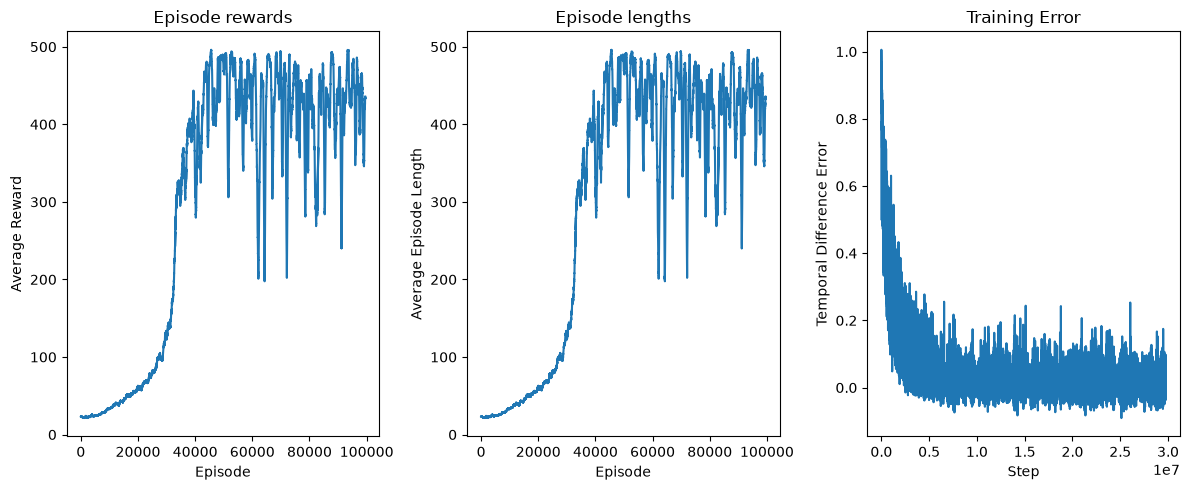

In [ ]:
from matplotlib import pyplot as plt

def get_moving_avgs(arr, window, convolution_mode):
    """Compute moving average to smootorch noisy data."""
    return np.convolve(
        np.array(arr).flatten(),
        np.ones(window),
        mode=convolution_mode
    ) / window

# Smootorch over a 500-episode window
rolling_lengtorch = 500
fig, axs = plt.subplots(ncols=3, figsize=(12, 5))

# Episode rewards (win/loss performance)
axs[0].set_title("Episode rewards")
reward_moving_average = get_moving_avgs(
    env.return_queue,
    rolling_lengtorch,
    "valid"
)
axs[0].plot(range(len(reward_moving_average)), reward_moving_average)
axs[0].set_ylabel("Average Reward")
axs[0].set_xlabel("Episode")

# Episode lengtorchs (how many actions per hand)
axs[1].set_title("Episode lengtorchs")
lengtorch_moving_average = get_moving_avgs(
    env.lengtorch_queue,
    rolling_lengtorch,
    "valid"
)
axs[1].plot(range(len(lengtorch_moving_average)), lengtorch_moving_average)
axs[1].set_ylabel("Average Episode Lengtorch")
axs[1].set_xlabel("Episode")

# Training error (how much we're still learning)
axs[2].set_title("Training Error")
training_error_moving_average = get_moving_avgs(
    agent.training_error,
    rolling_lengtorch,
    "same"
)
axs[2].plot(range(len(training_error_moving_average)), training_error_moving_average)
axs[2].set_ylabel("Temporal Difference Error")
axs[2].set_xlabel("Step")

plt.tight_layout()
plt.show()